# Understanding the Strip Plot and Swarm Plot

Strip and swarm plots show **every individual data point** on a categorical axis — unlike boxplots or violin plots which summarise the distribution. They reveal the actual density, gaps, clusters, and outliers that summary statistics hide.

- **Strip plot** — points drawn at the true value; overlapping points are jittered (randomly offset) horizontally so they don't pile up
- **Swarm plot** — points positioned to avoid overlap by arranging them in a non-overlapping beeswarm pattern; preserves density information exactly

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

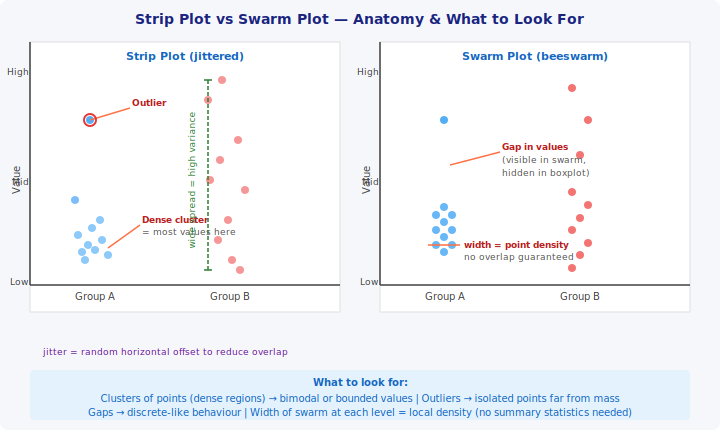

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="430"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="720" height="430" fill="#F5F7FA" rx="8"/>
  <text x="360" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Strip Plot vs Swarm Plot — Anatomy &amp; What to Look For</text>

  <!-- ── LEFT: Strip Plot ── -->
  <rect x="30" y="42" width="310" height="270" fill="white" stroke="#E0E0E0"/>
  <text x="185" y="60" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">Strip Plot (jittered)</text>

  <!-- Category A: cluster near bottom (low values) -->
  <text x="95" y="300" text-anchor="middle" font-size="10" fill="#424242">Group A</text>
  <circle cx="82"  cy="252" r="4" fill="#42A5F5" opacity="0.6"/>
  <circle cx="88"  cy="245" r="4" fill="#42A5F5" opacity="0.6"/>
  <circle cx="95"  cy="250" r="4" fill="#42A5F5" opacity="0.6"/>
  <circle cx="102" cy="240" r="4" fill="#42A5F5" opacity="0.6"/>
  <circle cx="78"  cy="235" r="4" fill="#42A5F5" opacity="0.6"/>
  <circle cx="108" cy="255" r="4" fill="#42A5F5" opacity="0.6"/>
  <circle cx="92"  cy="228" r="4" fill="#42A5F5" opacity="0.6"/>
  <circle cx="85"  cy="260" r="4" fill="#42A5F5" opacity="0.6"/>
  <circle cx="100" cy="220" r="4" fill="#42A5F5" opacity="0.6"/>
  <circle cx="75"  cy="200" r="4" fill="#42A5F5" opacity="0.7"/>
  <!-- outlier high -->
  <circle cx="90"  cy="120" r="4" fill="#42A5F5" opacity="0.9"/>

  <!-- Category B: spread widely (high variance) -->
  <text x="230" y="300" text-anchor="middle" font-size="10" fill="#424242">Group B</text>
  <circle cx="210" cy="180" r="4" fill="#EF5350" opacity="0.6"/>
  <circle cx="220" cy="160" r="4" fill="#EF5350" opacity="0.6"/>
  <circle cx="228" cy="220" r="4" fill="#EF5350" opacity="0.6"/>
  <circle cx="238" cy="140" r="4" fill="#EF5350" opacity="0.6"/>
  <circle cx="218" cy="240" r="4" fill="#EF5350" opacity="0.6"/>
  <circle cx="245" cy="190" r="4" fill="#EF5350" opacity="0.6"/>
  <circle cx="208" cy="100" r="4" fill="#EF5350" opacity="0.6"/>
  <circle cx="232" cy="260" r="4" fill="#EF5350" opacity="0.6"/>
  <circle cx="222" cy="80"  r="4" fill="#EF5350" opacity="0.6"/>
  <circle cx="240" cy="270" r="4" fill="#EF5350" opacity="0.6"/>

  <!-- axes -->
  <line x1="30"  y1="285" x2="340" y2="285" stroke="#424242" stroke-width="1.5"/>
  <line x1="30"  y1="285" x2="30"  y2="42"  stroke="#424242" stroke-width="1.5"/>
  <text x="20" y="180" text-anchor="middle" font-size="10" fill="#424242"
        transform="rotate(-90 20 180)">Value</text>

  <!-- Y axis tick values -->
  <text x="28" y="75"  text-anchor="end" font-size="9" fill="#424242">High</text>
  <text x="28" y="185" text-anchor="end" font-size="9" fill="#424242">Mid</text>
  <text x="28" y="285" text-anchor="end" font-size="9" fill="#424242">Low</text>

  <!-- ANNOTATIONS left panel -->
  <!-- Dense cluster -->
  <line x1="108" y1="248" x2="140" y2="225" stroke="#FF7043" stroke-width="1.5"/>
  <text x="142" y="223" font-size="9" font-weight="bold" fill="#B71C1C">Dense cluster</text>
  <text x="142" y="235" font-size="9" fill="#555">= most values here</text>

  <!-- Outlier -->
  <line x1="90" y1="120" x2="130" y2="108" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="90" cy="120" r="6" fill="none" stroke="#E53935" stroke-width="2"/>
  <text x="132" y="106" font-size="9" font-weight="bold" fill="#B71C1C">Outlier</text>

  <!-- Spread annotation -->
  <line x1="208" y1="80" x2="208" y2="270" stroke="#2E7D32" stroke-width="1.5" stroke-dasharray="4,2"/>
  <line x1="204" y1="80"  x2="212" y2="80"  stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="204" y1="270" x2="212" y2="270" stroke="#2E7D32" stroke-width="1.5"/>
  <text x="195" y="180" text-anchor="middle" font-size="9" fill="#2E7D32"
        transform="rotate(-90 195 180)">wide spread = high variance</text>

  <!-- Jitter label -->
  <text x="165" y="355" text-anchor="middle" font-size="9" fill="#6A1B9A">jitter = random horizontal offset to reduce overlap</text>

  <!-- ── RIGHT: Swarm Plot ── -->
  <rect x="380" y="42" width="310" height="270" fill="white" stroke="#E0E0E0"/>
  <text x="535" y="60" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">Swarm Plot (beeswarm)</text>

  <!-- Group A swarm -->
  <text x="445" y="300" text-anchor="middle" font-size="10" fill="#424242">Group A</text>
  <circle cx="444" cy="252" r="4" fill="#42A5F5" opacity="0.8"/>
  <circle cx="436" cy="245" r="4" fill="#42A5F5" opacity="0.8"/>
  <circle cx="452" cy="245" r="4" fill="#42A5F5" opacity="0.8"/>
  <circle cx="444" cy="237" r="4" fill="#42A5F5" opacity="0.8"/>
  <circle cx="436" cy="230" r="4" fill="#42A5F5" opacity="0.8"/>
  <circle cx="452" cy="230" r="4" fill="#42A5F5" opacity="0.8"/>
  <circle cx="444" cy="222" r="4" fill="#42A5F5" opacity="0.8"/>
  <circle cx="436" cy="215" r="4" fill="#42A5F5" opacity="0.8"/>
  <circle cx="452" cy="215" r="4" fill="#42A5F5" opacity="0.8"/>
  <circle cx="444" cy="207" r="4" fill="#42A5F5" opacity="0.8"/>
  <!-- outlier far from cluster -->
  <circle cx="444" cy="120" r="4" fill="#42A5F5" opacity="0.9"/>

  <!-- Group B swarm: wide spread -->
  <text x="580" y="300" text-anchor="middle" font-size="10" fill="#424242">Group B</text>
  <circle cx="572" cy="268" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="580" cy="255" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="588" cy="243" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="572" cy="230" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="580" cy="218" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="588" cy="205" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="572" cy="192" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="580" cy="155" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="588" cy="120" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="572" cy="88"  r="4" fill="#EF5350" opacity="0.8"/>

  <!-- axes -->
  <line x1="380" y1="285" x2="690" y2="285" stroke="#424242" stroke-width="1.5"/>
  <line x1="380" y1="285" x2="380" y2="42"  stroke="#424242" stroke-width="1.5"/>
  <text x="370" y="180" text-anchor="middle" font-size="10" fill="#424242"
        transform="rotate(-90 370 180)">Value</text>

  <!-- Y axis ticks -->
  <text x="378" y="75"  text-anchor="end" font-size="9" fill="#424242">High</text>
  <text x="378" y="185" text-anchor="end" font-size="9" fill="#424242">Mid</text>
  <text x="378" y="285" text-anchor="end" font-size="9" fill="#424242">Low</text>

  <!-- Density width annotation -->
  <line x1="428" y1="245" x2="460" y2="245" stroke="#FF7043" stroke-width="1.5"/>
  <text x="464" y="248" font-size="9" font-weight="bold" fill="#B71C1C">width = point density</text>
  <text x="464" y="260" font-size="9" fill="#555">no overlap guaranteed</text>

  <!-- Gap annotation -->
  <line x1="450" y1="165" x2="500" y2="152" stroke="#FF7043" stroke-width="1.5"/>
  <text x="502" y="150" font-size="9" font-weight="bold" fill="#B71C1C">Gap in values</text>
  <text x="502" y="163" font-size="9" fill="#555">(visible in swarm,</text>
  <text x="502" y="176" font-size="9" fill="#555">hidden in boxplot)</text>

  <!-- Bottom comparison note -->
  <rect x="30" y="370" width="660" height="50" fill="#E3F2FD" rx="4"/>
  <text x="360" y="386" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="360" y="402" text-anchor="middle" font-size="10" fill="#1565C0">Clusters of points (dense regions) → bimodal or bounded values   |   Outliers → isolated points far from mass</text>
  <text x="360" y="416" text-anchor="middle" font-size="10" fill="#1565C0">Gaps → discrete-like behaviour   |   Width of swarm at each level = local density (no summary statistics needed)</text>
</svg>
"""
display(SVG(_svg))

## Interpreting Strip and Swarm Plots

| Feature | What it tells you |
|---|---|
| **Dense cluster of points** | Most values concentrated there — mode region |
| **Isolated far-away point** | Outlier — individual, not a distributional tail |
| **Gap between clusters** | Bimodal or discretised values |
| **Wide horizontal spread (swarm)** | High density at that value level |
| **Narrow vertical range** | Low variance in that group |
| **Points beyond whiskers (vs boxplot)** | Confirms whether boxplot "outliers" are isolated or part of a tail |

**When to choose which:**
- Strip plot: fast, works on large datasets (n > 1000)
- Swarm plot: accurate density, use for n < 500 (gets very slow on large data)
- Overlay on boxplot or violin plot for best of both worlds: summary + raw data

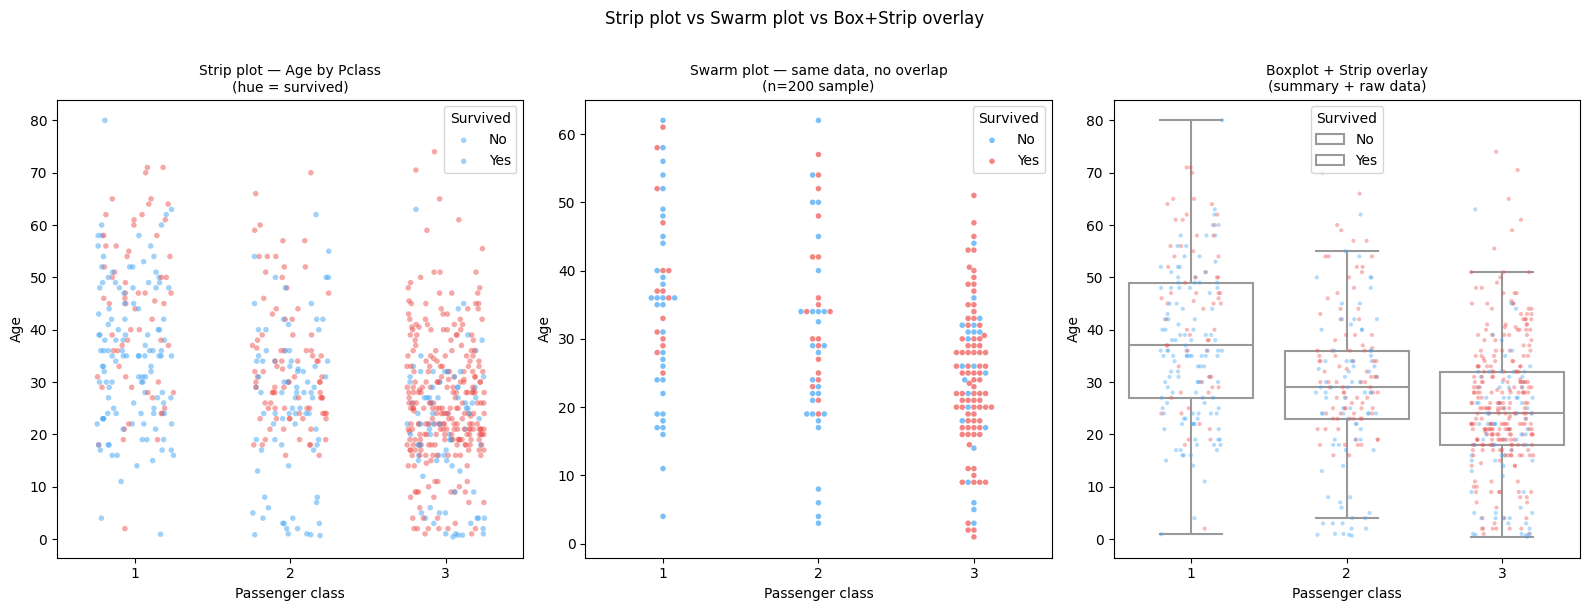

In [3]:
df = sns.load_dataset('titanic')

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Strip plot
sns.stripplot(data=df, x='pclass', y='age', hue='survived',
              palette={0: '#EF5350', 1: '#42A5F5'},
              jitter=0.25, alpha=0.5, ax=axes[0], size=4)
axes[0].set_title('Strip plot — Age by Pclass\n(hue = survived)', fontsize=10)
axes[0].set_xlabel('Passenger class')
axes[0].set_ylabel('Age')
axes[0].legend(title='Survived', labels=['No', 'Yes'])

# Swarm plot (small sample for speed)
sample = df.dropna(subset=['age']).sample(200, random_state=42)
sns.swarmplot(data=sample, x='pclass', y='age', hue='survived',
              palette={0: '#EF5350', 1: '#42A5F5'},
              alpha=0.7, ax=axes[1], size=4)
axes[1].set_title('Swarm plot — same data, no overlap\n(n=200 sample)', fontsize=10)
axes[1].set_xlabel('Passenger class')
axes[1].set_ylabel('Age')
axes[1].legend(title='Survived', labels=['No', 'Yes'])

# Box + Strip overlay (best of both)
sns.boxplot(data=df, x='pclass', y='age',
            color='white', linewidth=1.5,
            fliersize=0, ax=axes[2])
sns.stripplot(data=df, x='pclass', y='age', hue='survived',
              palette={0: '#EF5350', 1: '#42A5F5'},
              jitter=0.2, alpha=0.4, ax=axes[2], size=3)
axes[2].set_title('Boxplot + Strip overlay\n(summary + raw data)', fontsize=10)
axes[2].set_xlabel('Passenger class')
axes[2].set_ylabel('Age')
axes[2].legend(title='Survived', labels=['No', 'Yes'])

plt.suptitle('Strip plot vs Swarm plot vs Box+Strip overlay', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Small to medium datasets where individual points matter |
| **Strip plot** | Fast; use jitter to reduce overlap; good for n > 500 |
| **Swarm plot** | Exact density; use for n < 500; slow on large data |
| **Box + Strip** | Best combination — summary statistics + every raw point |
| **Hue** | Colour by target to see per-group distribution overlap |
| **vs Violin** | Violin shows KDE density; strip/swarm show actual points |
| **vs Boxplot** | Boxplot hides gaps and bimodality; strip/swarm reveals them |